# Inspecting logits

In [1]:
import torch
from transformers import AutoModelForCausalLM

def compare_llms(model1_name, model2_name, device='cuda'):
    # Load models to specified device (GPU)
    model1 = AutoModelForCausalLM.from_pretrained(model1_name, trust_remote_code=True).to(device)
    model2 = AutoModelForCausalLM.from_pretrained(model2_name, trust_remote_code=True).to(device)
    
    with torch.no_grad():
        # Extract and flatten parameters (excluding biases) in batches to save memory
        # Extract and flatten all parameters (excluding biases)
        θ1 = torch.cat([p.flatten() for n, p in model1.named_parameters() if "bias" not in n])
        θ2 = torch.cat([p.flatten() for n, p in model2.named_parameters() if "bias" not in n])

        N = θ1.numel()  # or θ2.numel() - should be the same
        
        # Normalize (stable computation for large vectors)
        θ1 = (θ1 - θ1.mean()) / (θ1.std() + 1e-8)  # Add epsilon for numerical stability
        θ2 = (θ2 - θ2.mean()) / (θ2.std() + 1e-8)
        
        # Compute metrics
        l2_dist = torch.norm(θ1 - θ2, p=2).item()
        l1_dist = torch.norm(θ1 - θ2, p=1).item()
        cos_sim = torch.nn.functional.cosine_similarity(
            θ1.unsqueeze(0), θ2.unsqueeze(0), dim=1).item()
        
        # Free GPU memory
        del model1, model2, θ1, θ2
        torch.cuda.empty_cache()
        
    return {
        "l1_distance": l1_dist,
        "l2_distance": l2_dist,
        "cosine_similarity": cos_sim,
        "total_parameters": N,
        "device_used": device
    }

# Usage
results = compare_llms(
    model1_name="Qwen/Qwen3-0.6B-Base",
    model2_name="andresnowak/MNLP_M2_mcqa_model",
    device='cuda'  # or 'cuda:0' for multi-GPU
)
print(results)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

{'l1_distance': 158415.265625, 'l2_distance': 37.76042556762695, 'cosine_similarity': 0.9999987483024597, 'total_parameters': 596049920, 'device_used': 'cuda'}


Both models are pretty similar it seems, fientuning just does small changes

jupyter-notebook --no-browser --port=8888 --ip=$(hostname -i)

In [2]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

def visualize_top_k_logits(model_name, prompt, device="cuda"):
    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to(device)
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    outputs = model(**inputs)

    # Get the logits for the last token position (where the answer is predicted)
    logits = outputs.logits[0, -1, :]

    # Get the top k predictions
    k = 10  # Number of top predictions to show
    topk = torch.topk(logits, k)

    # Convert logits to probabilities (softmax)
    probs = torch.softmax(logits, dim=-1)
    topk_probs = torch.softmax(topk.values, dim=-1)

    # Get the tokens and their corresponding text
    tokens = topk.indices
    token_texts = [tokenizer.decode(token) for token in tokens]

    # Create a bar plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(k), topk_probs.cpu().detach().numpy())
    plt.xticks(range(k), token_texts, rotation=45, ha='right')
    plt.ylabel('Probability')
    plt.title(f'Top-{k} predicted tokens for the next word')

    # Add probability values on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [ ]:
prompt = """Question: Why does ice float on water?
(A) Because it is denser than water
(B) Because it is less dense than Water
(C) Because it has a different chemical structure
(D) Because of surface tension
(E) The same rules as oil
Answer:"""


tokenizer_config.json:   0%|          | 0.00/5.43k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

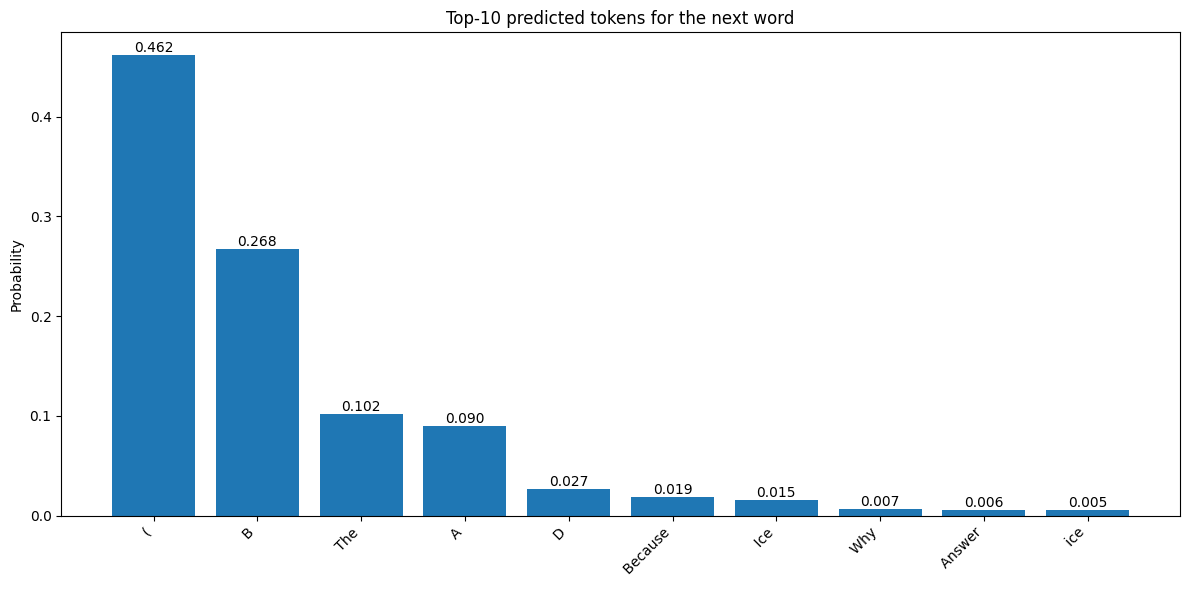

In [4]:
visualize_top_k_logits("andresnowak/MNLP_M2_mcqa_model", prompt)

tokenizer_config.json:   0%|          | 0.00/9.68k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

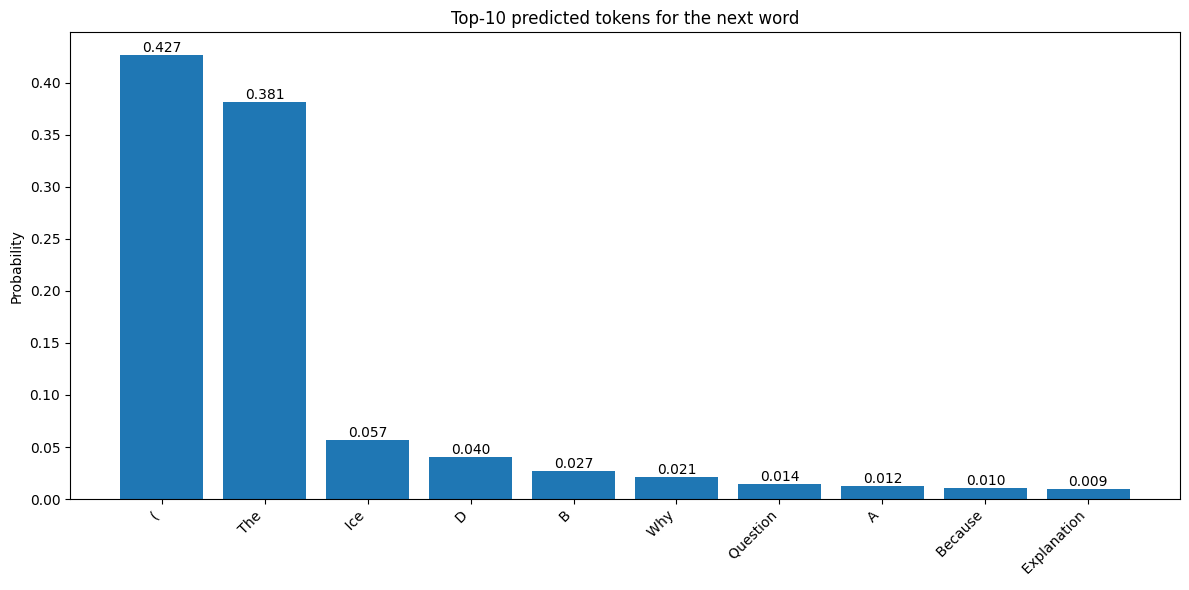

In [5]:
visualize_top_k_logits("Qwen/Qwen3-0.6B-Base", prompt)

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.54k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

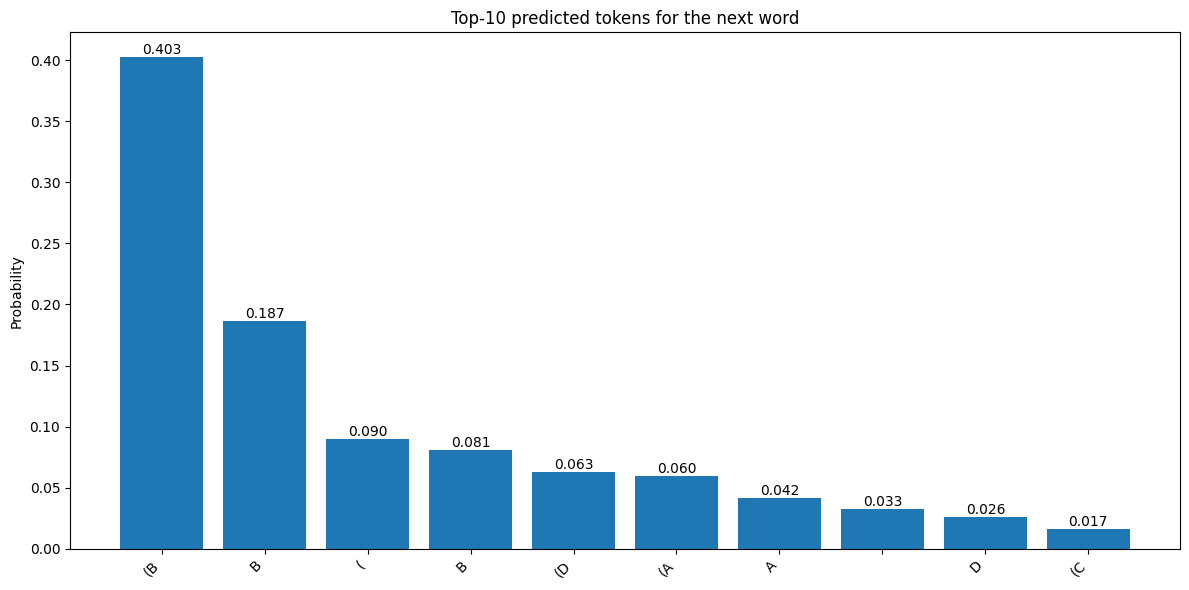

In [6]:
visualize_top_k_logits("andresnowak/Qwen3-0.6B-MNLP_mcqa_rl", prompt)

config.json:   0%|          | 0.00/785 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.43k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

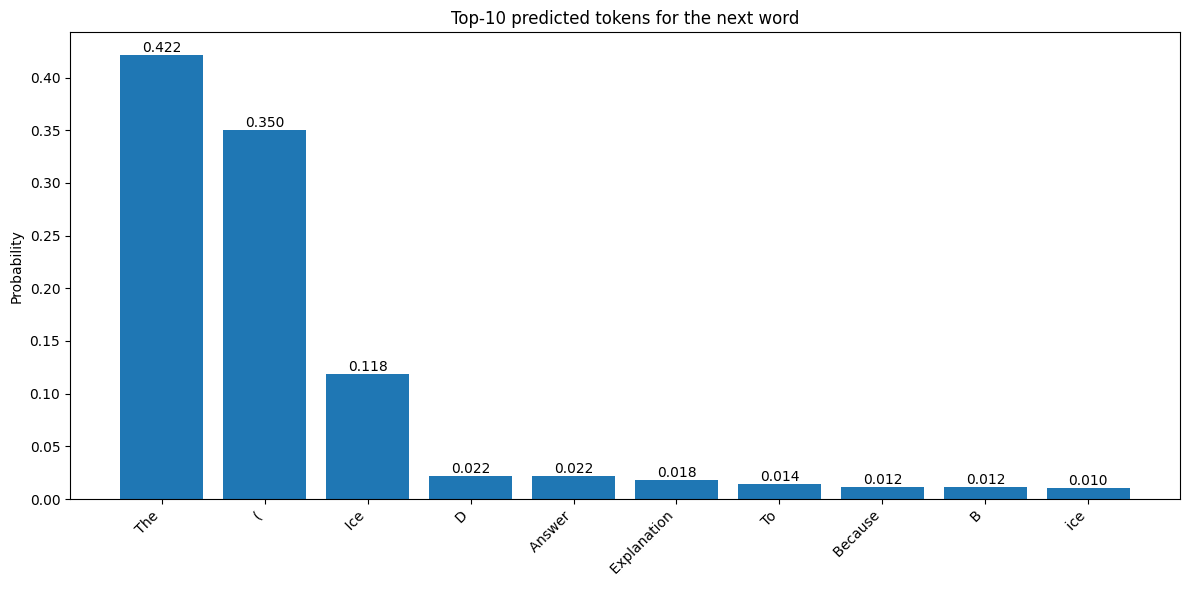

In [7]:
visualize_top_k_logits("andresnowak/Qwen3-0.6B-instruction-finetuned_v2", prompt)

In [8]:
from collections import defaultdict
import seaborn as sns

def record_top_k_tokens(model, tokenizer, dataset, k=20, device="cuda"):
    token_counts = defaultdict(int)
    prob_sums = defaultdict(float)
    
    for example in dataset:
        prompt = f"Question: {example['question']}\n"
        prompt += "\n".join([f"({chr(65+i)}) {choice}" for i, choice in enumerate(example["choices"])])
        prompt += "\nAnswer:"
        
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits = outputs.logits[0, -1, :]  # Last token logits
        probs = torch.softmax(logits, dim=-1)
        topk = torch.topk(probs, k)
        
        # Record top tokens and their probabilities
        for token_id, prob in zip(topk.indices, topk.values):
            token_text = tokenizer.decode(token_id)
            token_counts[token_text] += 1
            prob_sums[token_text] += prob.item()
    
    return token_counts, prob_sums


def visualize_over_dataset(model_name, dataset, name, save_path=None):
    model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to("cuda")
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

    # Record top-20 tokens across MMLU subset
    token_counts, prob_sums = record_top_k_tokens(model, tokenizer, dataset, k=20)

    # Sort tokens by frequency (most common first)
    sorted_tokens = sorted(token_counts.items(), key=lambda x: -x[1])

    # Extract top 20 most frequent tokens
    top_tokens = [token for token, count in sorted_tokens[:20]]
    counts = [count for token, count in sorted_tokens[:20]]
    avg_probs = [prob_sums[token] / counts[i] for i, token in enumerate(top_tokens)]

    # Plotting
    sns.set_style("whitegrid", {'grid.linestyle': ':', 'axes.edgecolor': '0.3'})
    plt.rcParams.update({
        'font.size': 12,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
        'savefig.dpi': 300,
    })

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))

    # Use a color palette suitable for b&w printing
    colors = sns.color_palette("viridis", len(top_tokens))
    bars = ax.bar(top_tokens, counts, color=colors, edgecolor='black', linewidth=0.5)

    # Customize axes and labels
    ax.set_ylabel("Frequency in Top-20", labelpad=10)
    ax.set_xlabel("Predicted Tokens", labelpad=10)
    ax.set_title(f"Most Common Top-20 Tokens in {name} Questions", pad=20)

    # Rotate x-labels and align for readability
    plt.xticks(rotation=45, ha='right', rotation_mode='anchor')

    # Add probability annotations with improved positioning
    for bar, prob in zip(bars, avg_probs):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2., 
            height + (0.01 * max(counts)),  # Slight vertical offset
            f"{prob:.3f}", 
            ha='center', 
            va='bottom',
            fontsize=10
        )

    # Add grid lines and adjust layout
    ax.yaxis.grid(True, linestyle=':', alpha=0.7)
    ax.set_axisbelow(True)  # Ensure grid is behind bars
    plt.tight_layout(pad=2.0)  # Prevent label cutoff

    # Save to PDF if path is provided
    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    plt.show()

In [9]:
from datasets import load_dataset

mmlu_dataset = load_dataset("TIGER-Lab/MMLU-STEM", split="test")
mmlu_subset = mmlu_dataset.shuffle(seed=42).select(range(1000))
print(f"Sampled {len(mmlu_subset)} examples.")

Sampled 1000 examples.


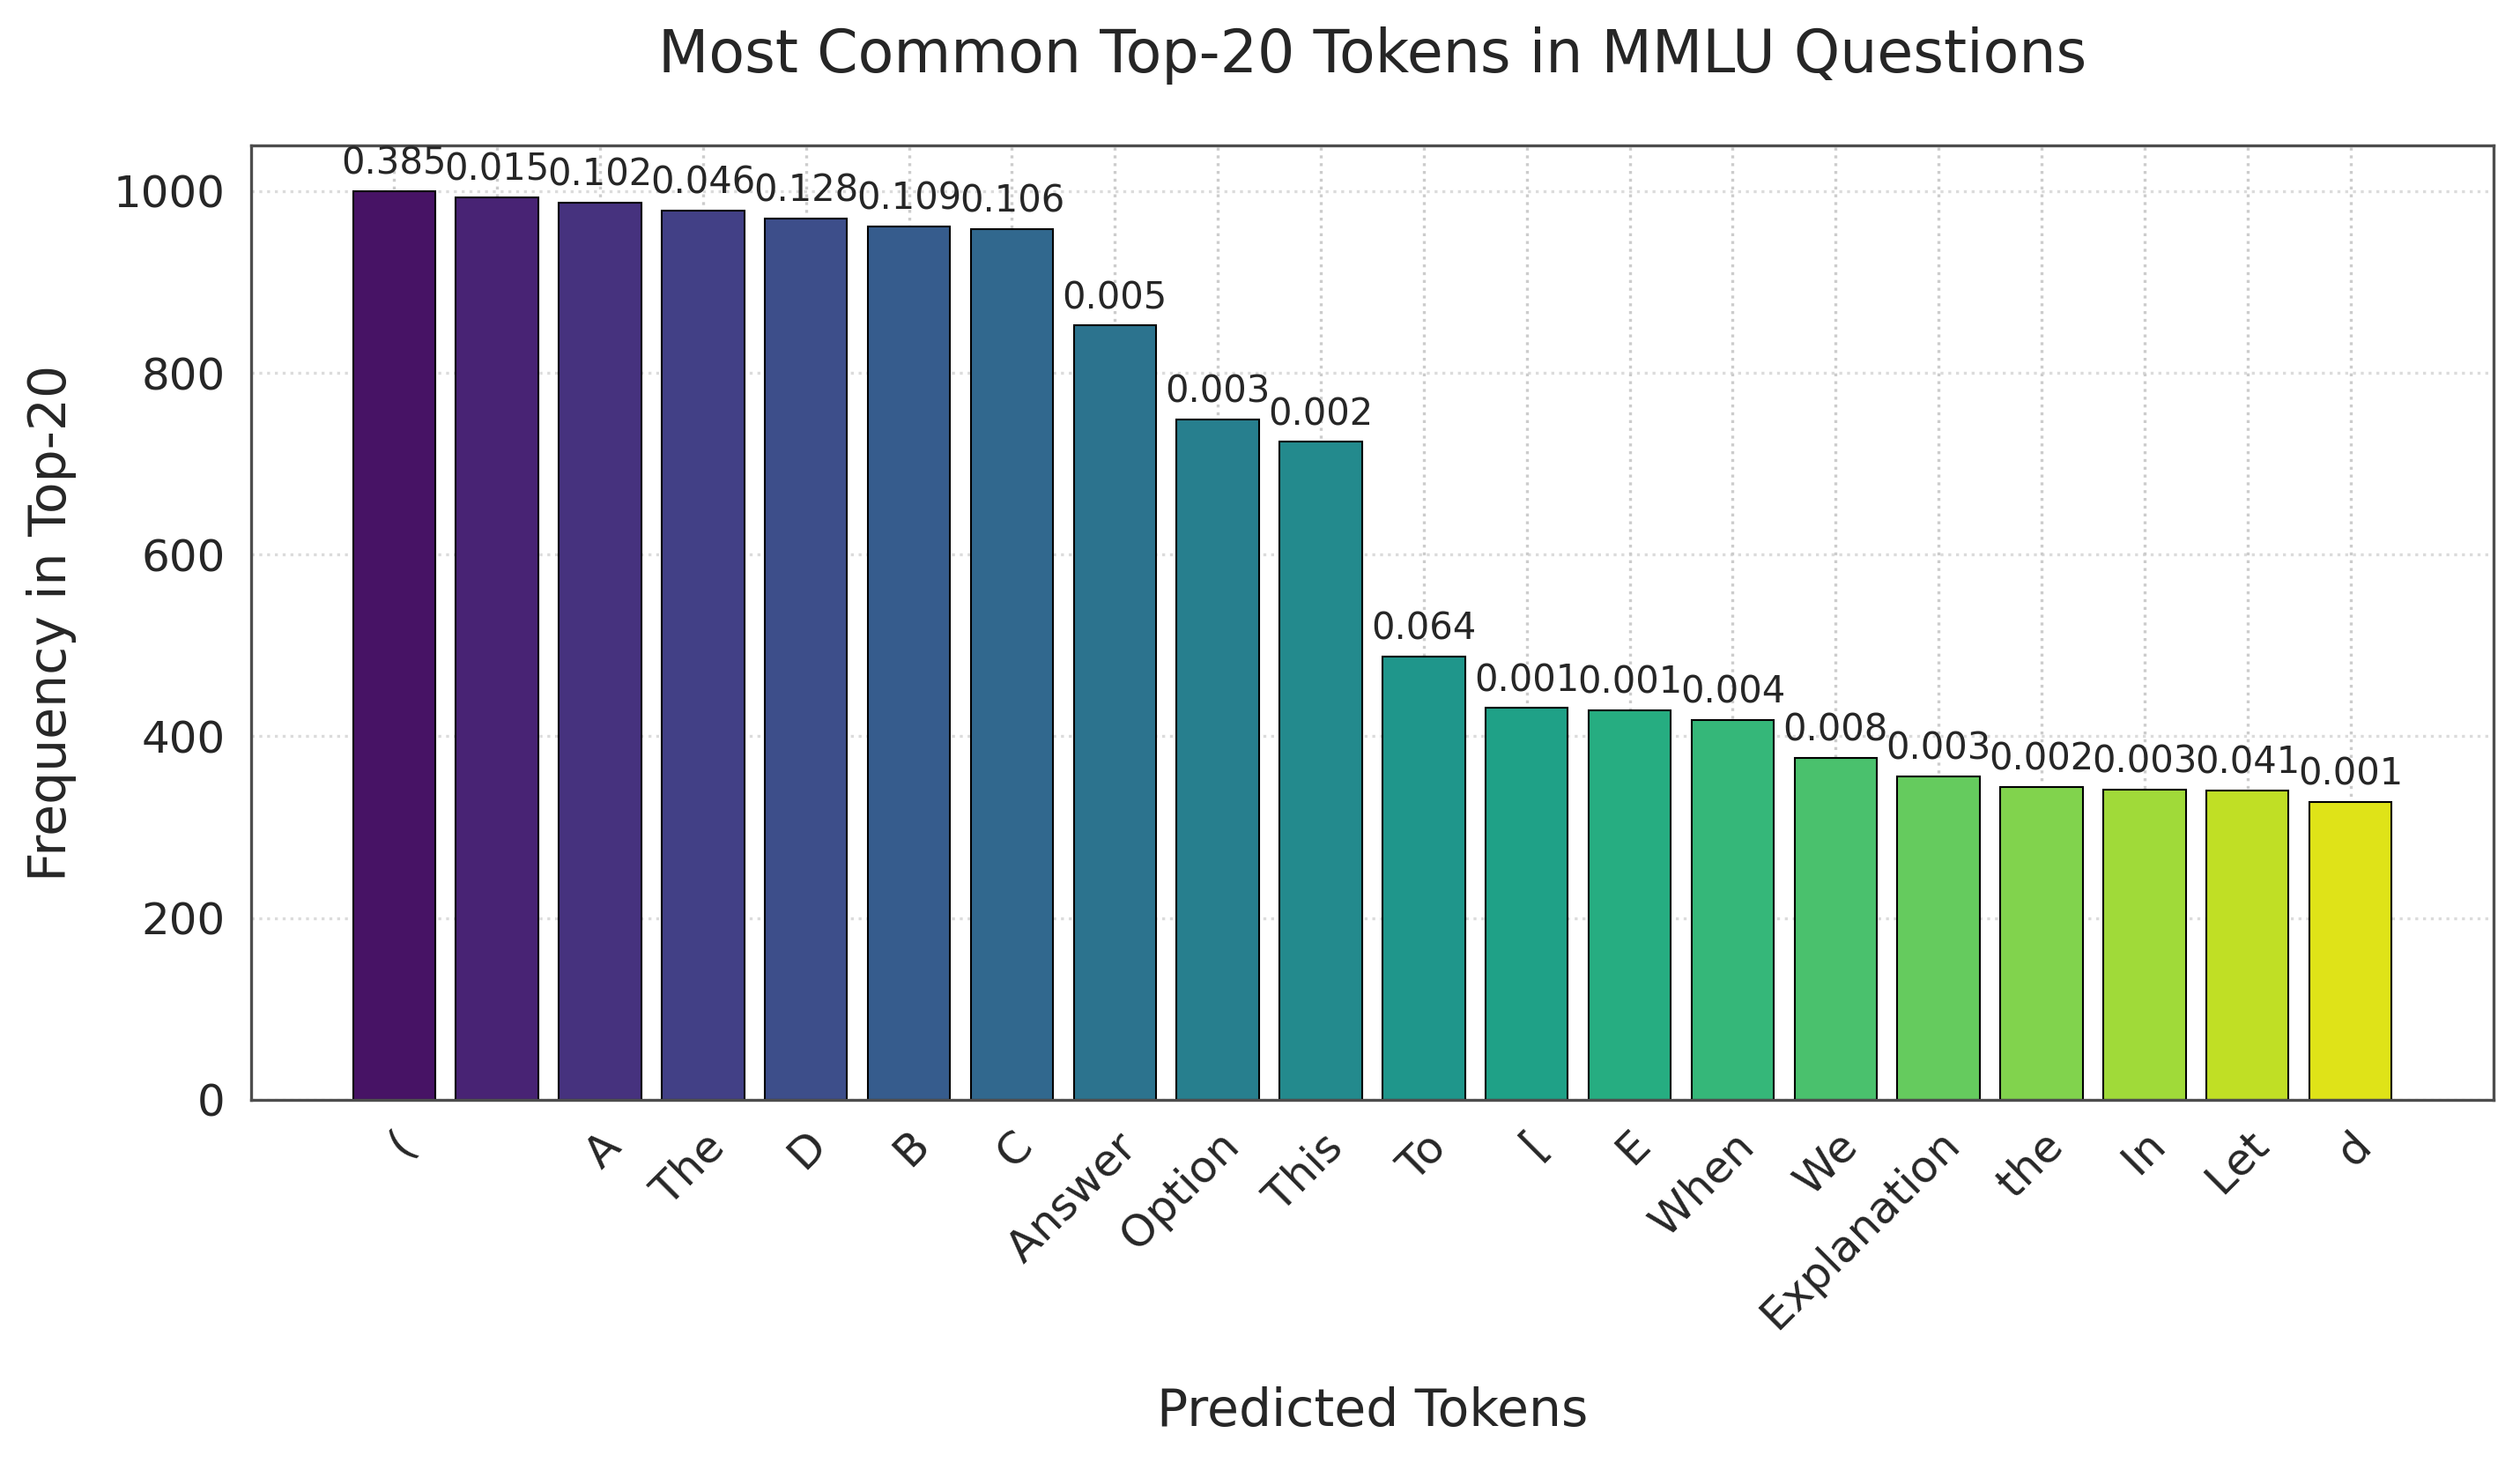

In [10]:
visualize_over_dataset("andresnowak/MNLP_M2_mcqa_model", mmlu_subset, "MMLU", "mcqa_mmlu_outputs.pdf")

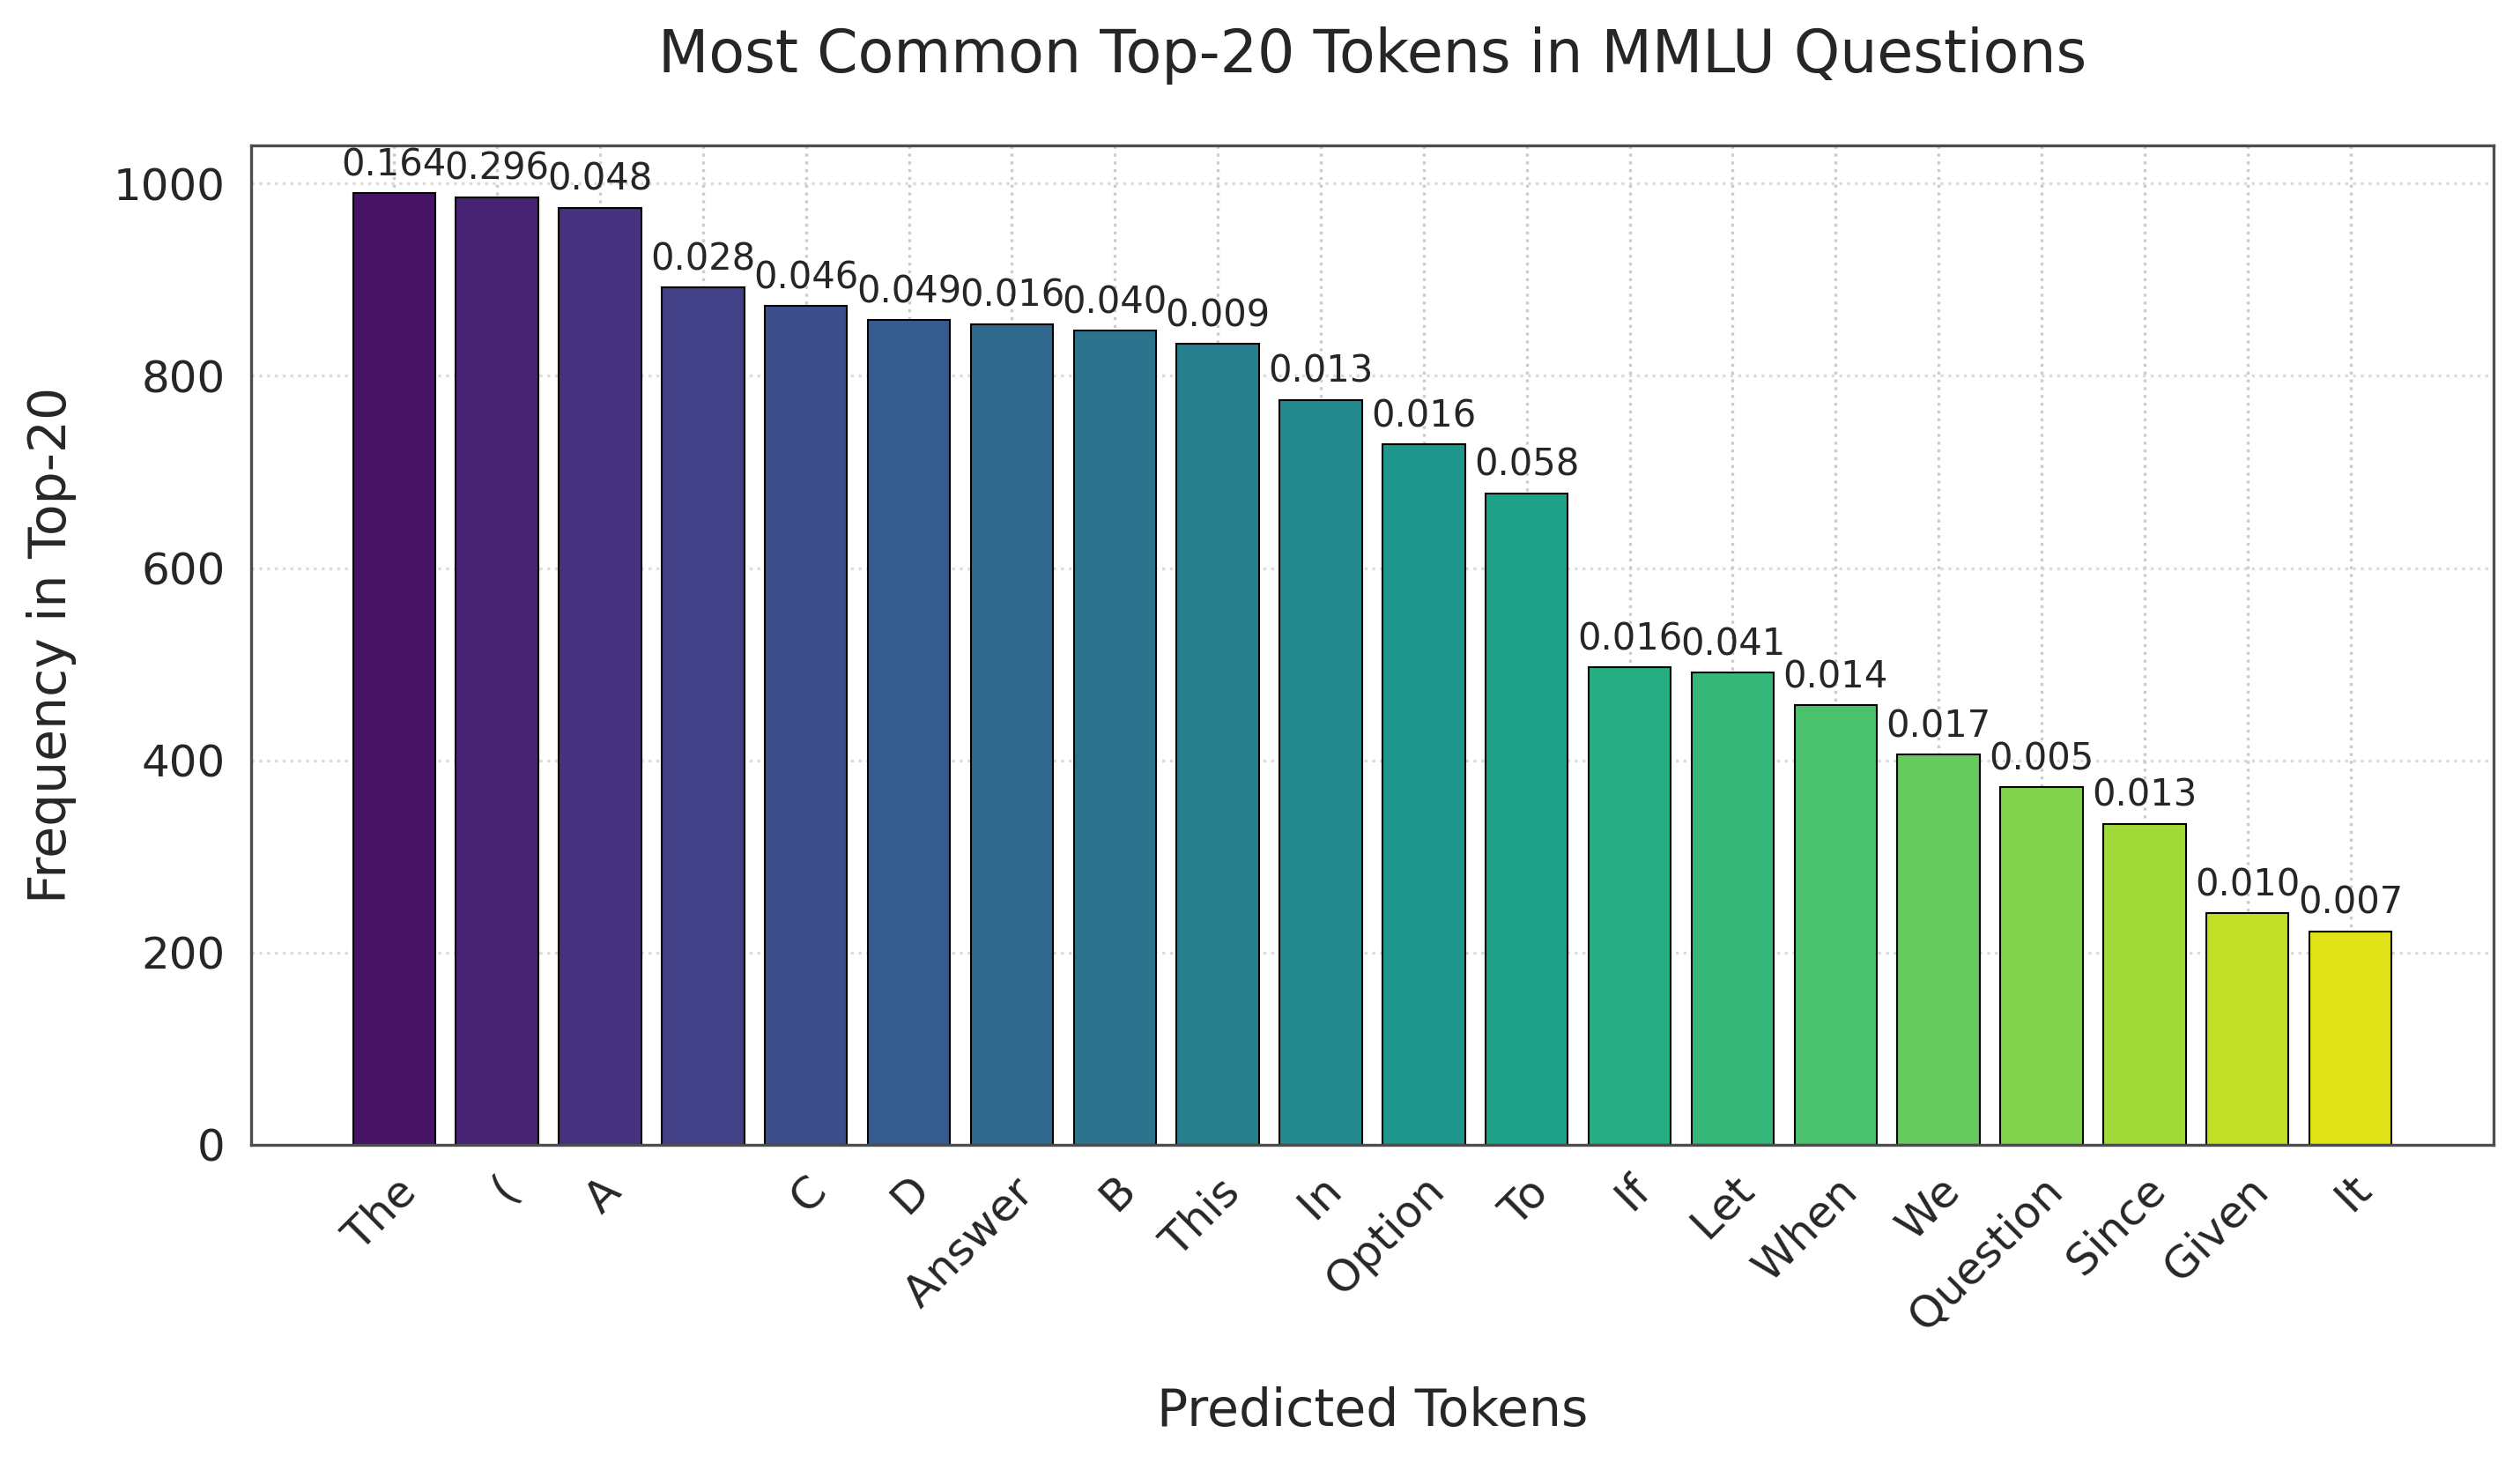

In [11]:
visualize_over_dataset("Qwen/Qwen3-0.6B-Base", mmlu_subset, "MMLU", "base_mmlu_outputs.pdf")

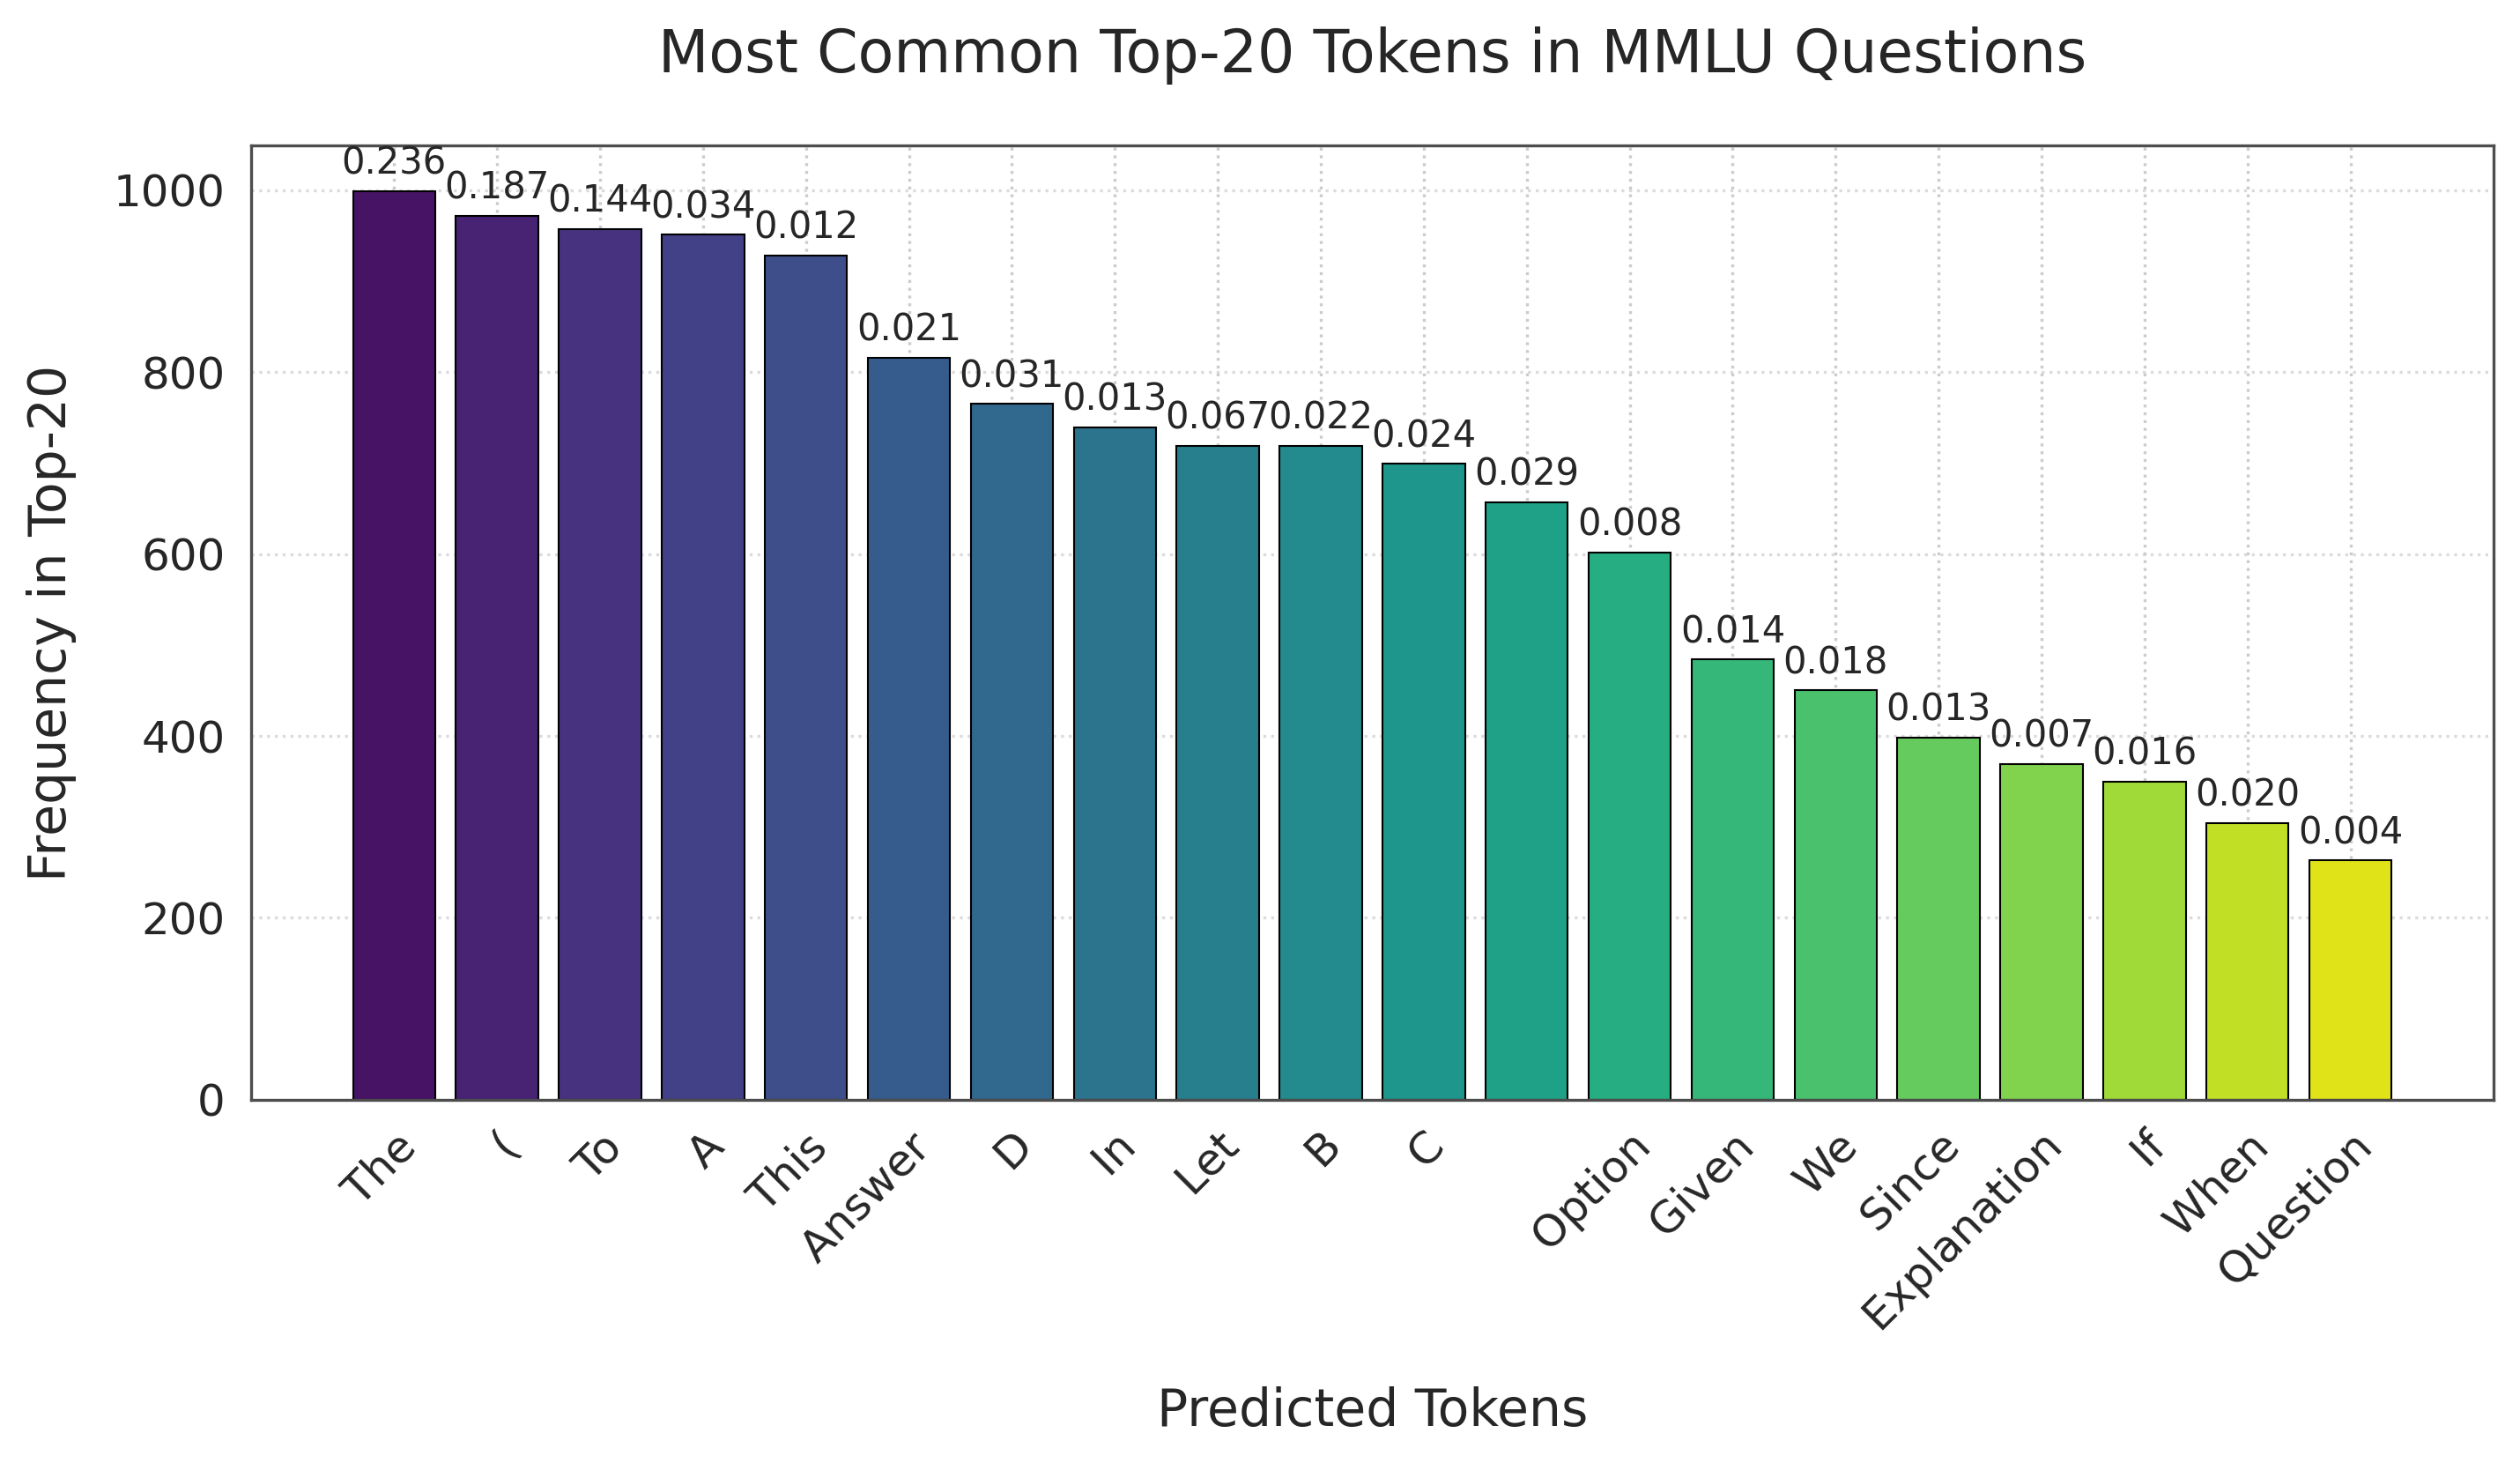

In [12]:
visualize_over_dataset("andresnowak/Qwen3-0.6B-instruction-finetuned_v2", mmlu_subset, "MMLU")

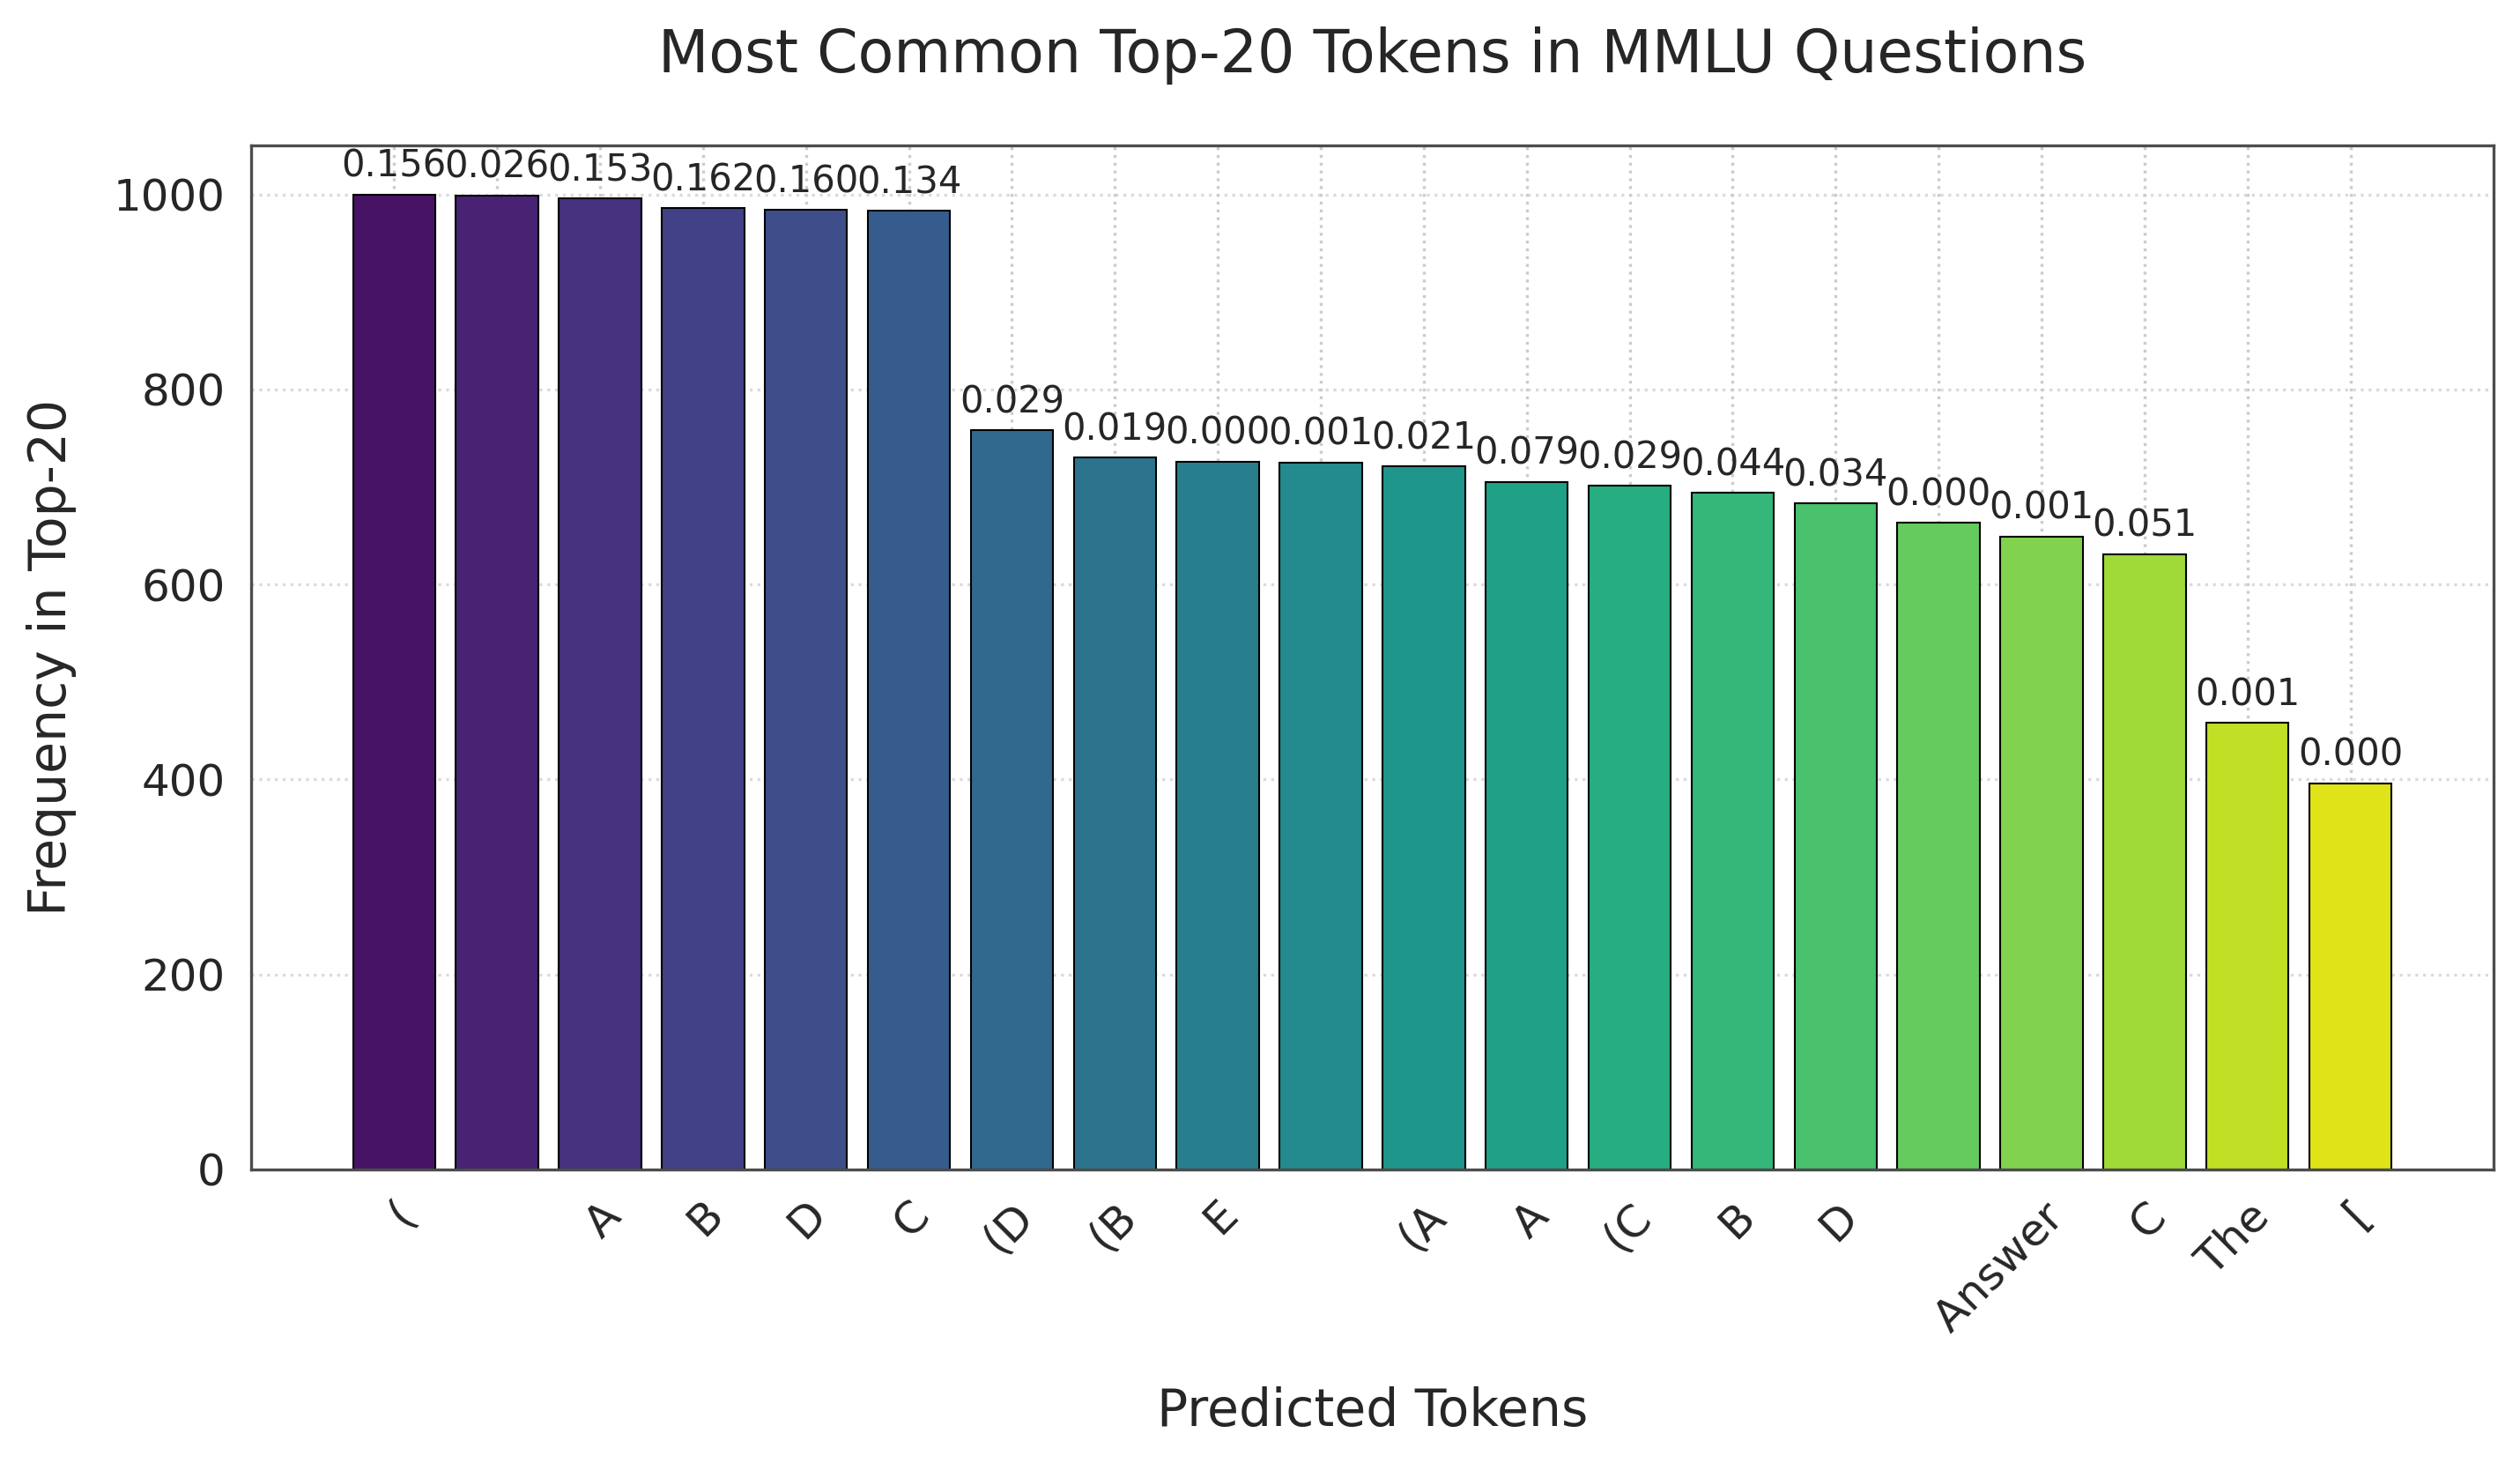

In [13]:
visualize_over_dataset("andresnowak/Qwen3-0.6B-MNLP_mcqa_rl", mmlu_subset, "MMLU")

In [14]:
mmlu_pro_dataset = load_dataset("TIGER-Lab/MMLU-Pro", split="test")
mmlu_pro_dataset = mmlu_pro_dataset.rename_column("options", "choices")
mmlu_pro_subset = mmlu_pro_dataset.shuffle(seed=42).select(range(1000))
print(f"Sampled {len(mmlu_pro_subset)} examples.")

Sampled 1000 examples.


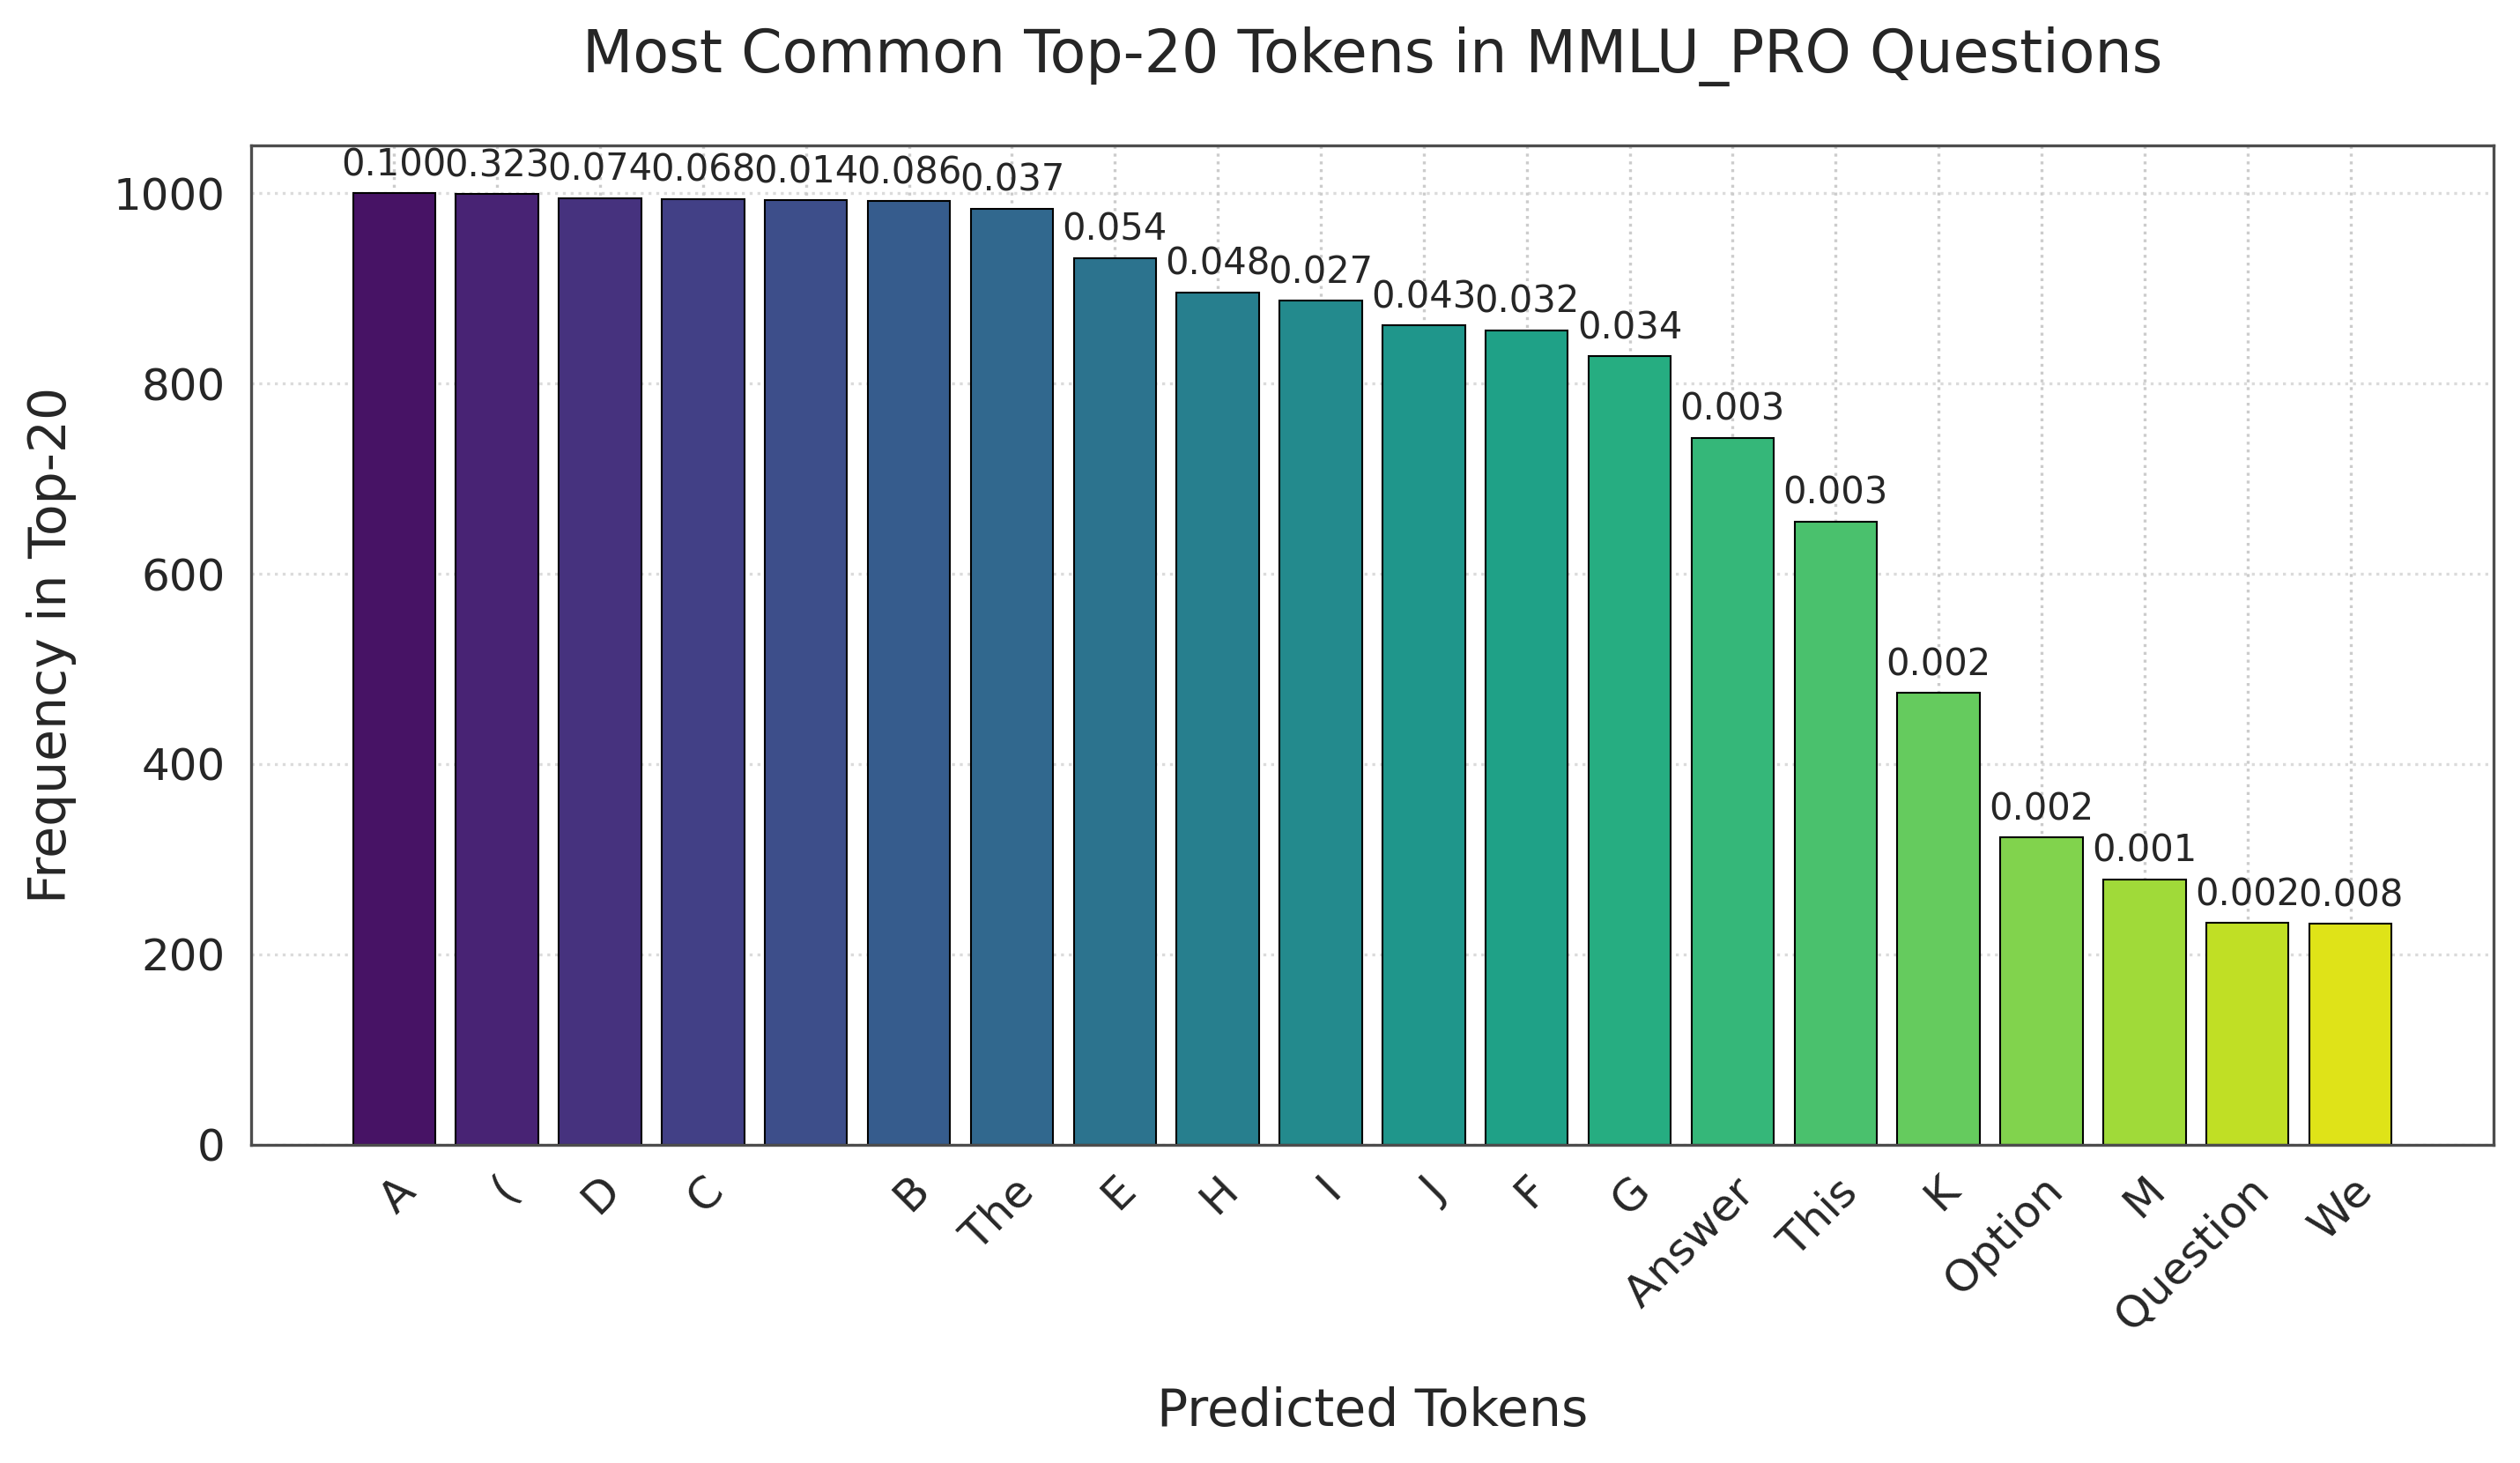

In [15]:
visualize_over_dataset("andresnowak/MNLP_M2_mcqa_model", mmlu_pro_subset, "MMLU_PRO", "mcqa_mmlu_pro_outputs.pdf")

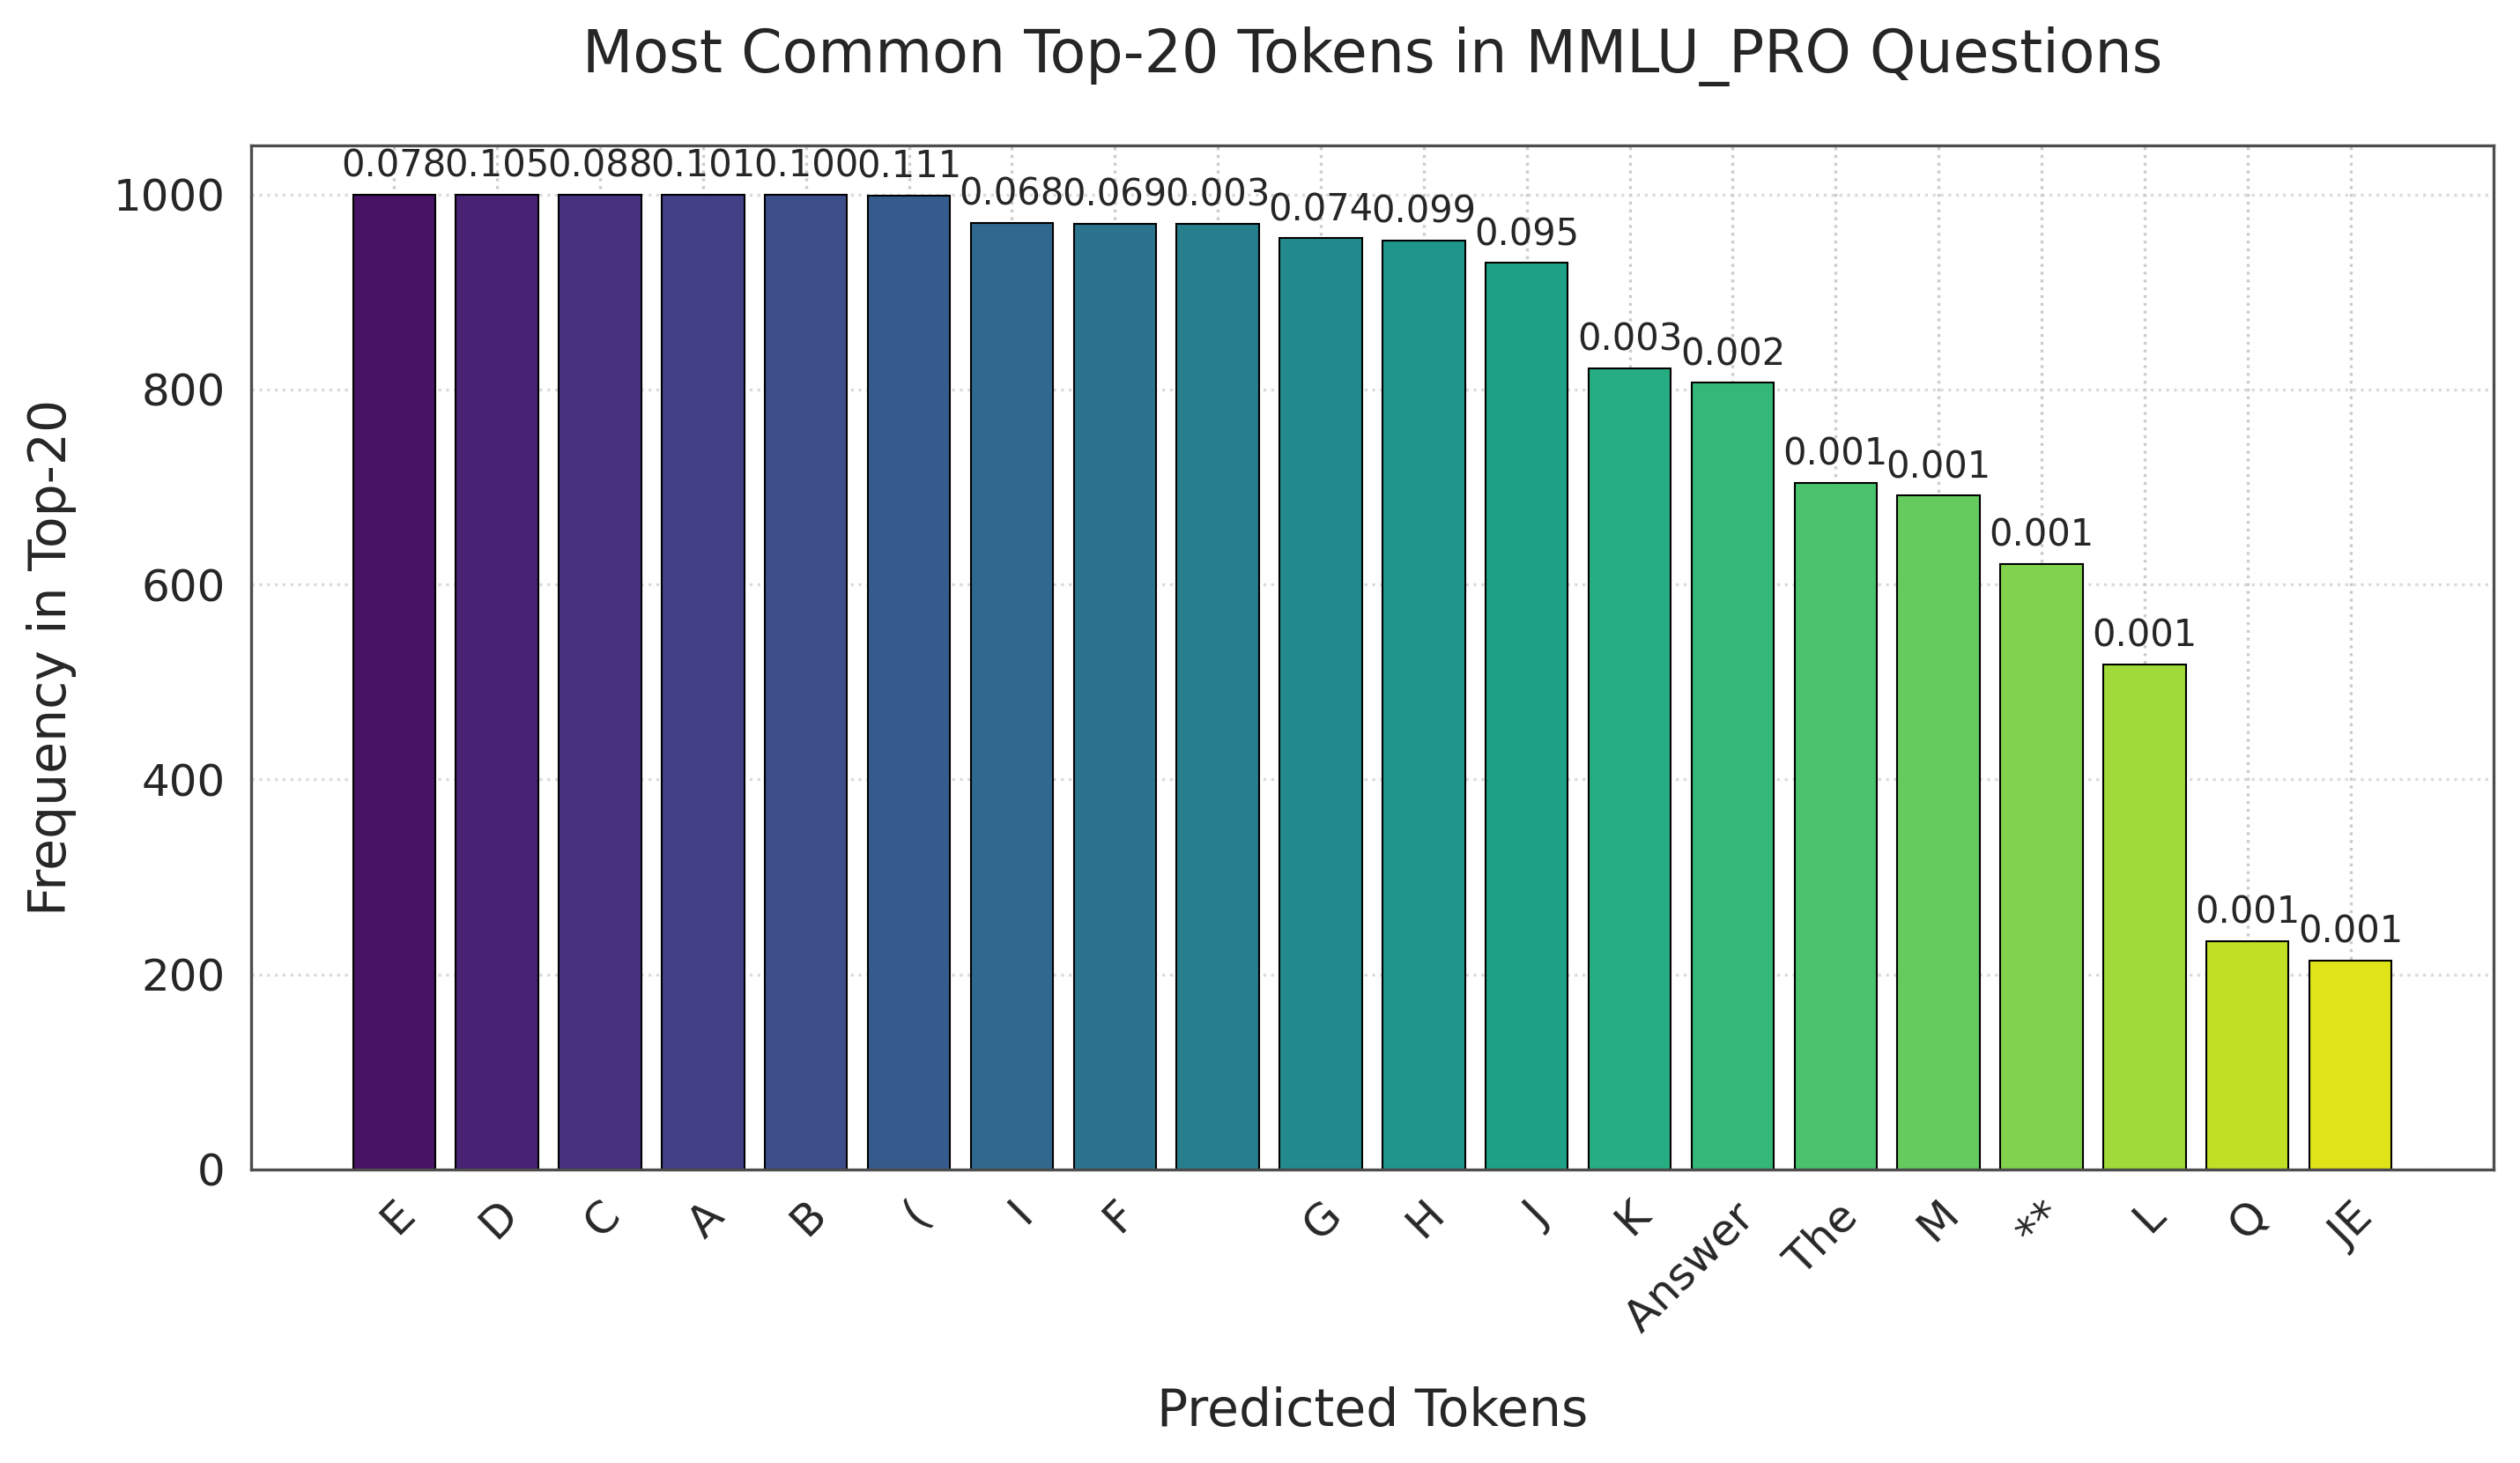

In [16]:
visualize_over_dataset("andresnowak/MNLP_M3_mcqa_model", mmlu_pro_subset, "MMLU_PRO", "mcqa_10_options_mmlu_pro_outputs.pdf")

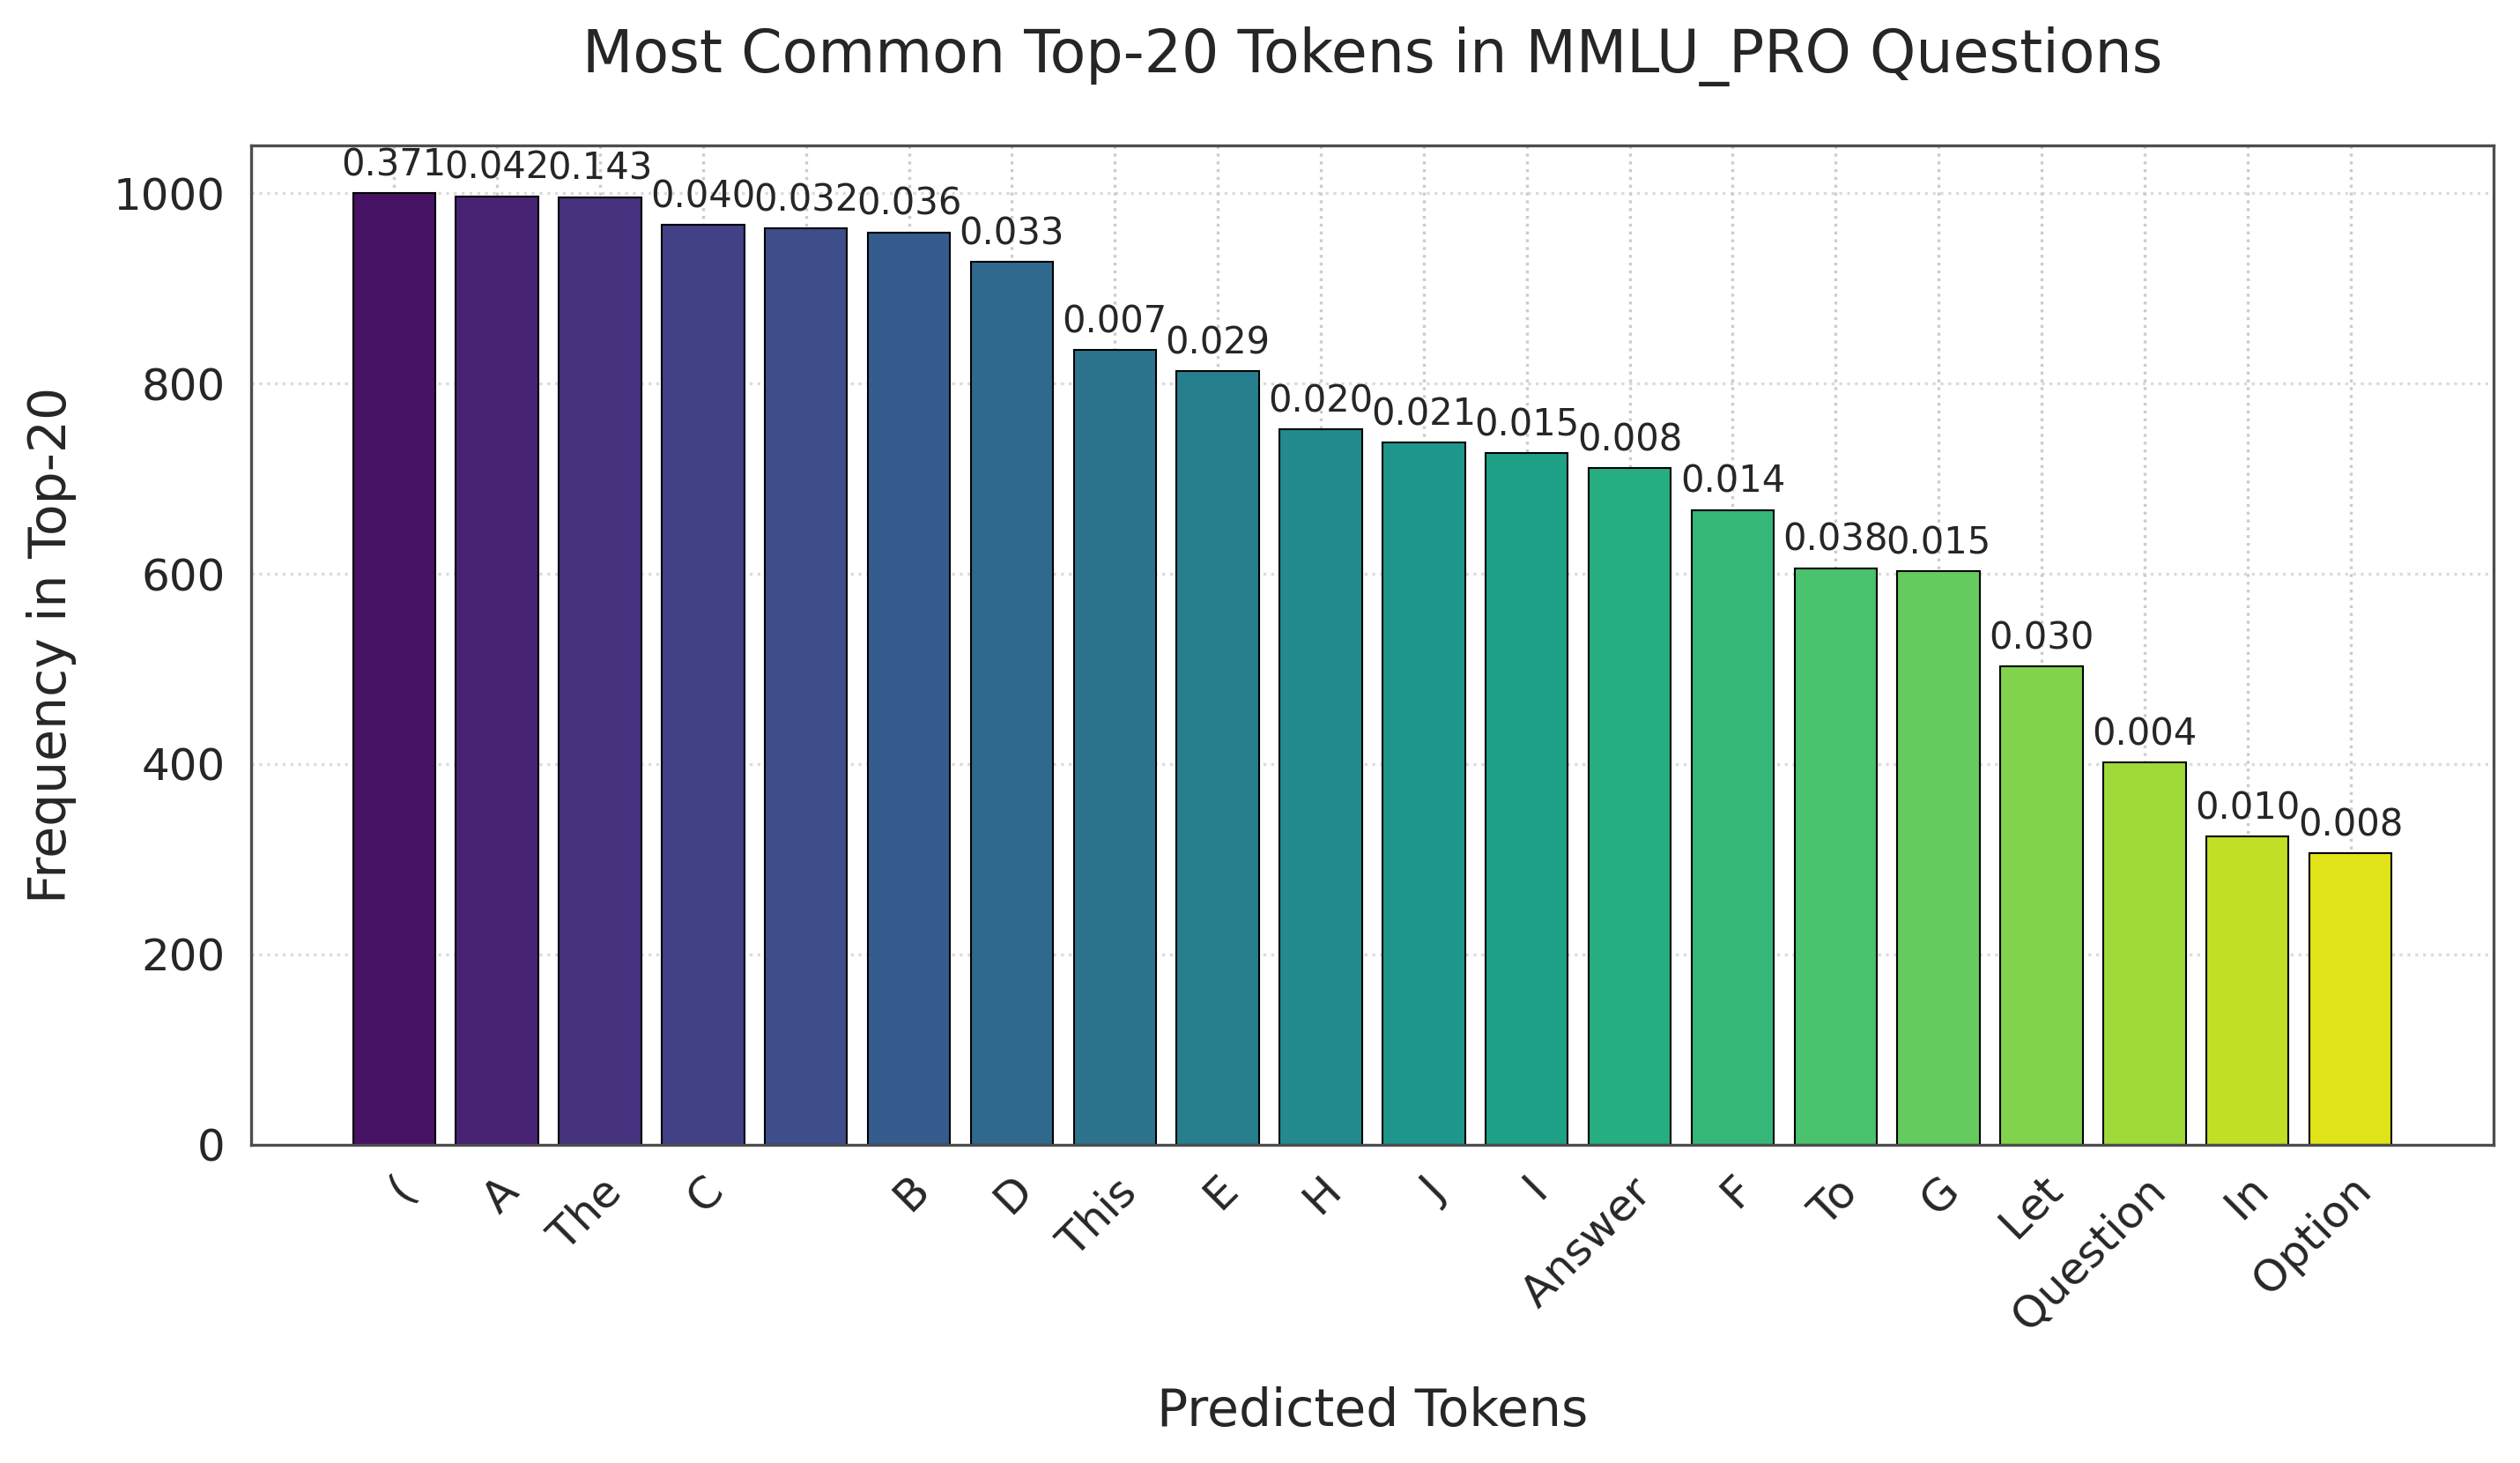

In [17]:
visualize_over_dataset("Qwen/Qwen3-0.6B-Base", mmlu_pro_subset, "MMLU_PRO", "base_mmlu_pro_outputs.pdf")